In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
print(df.shape)

(167, 10)


In [7]:
#Check Missing Values
df.isnull().sum()




country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [9]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [10]:
countries = df["country"]

X = df.drop("country", axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


In [12]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

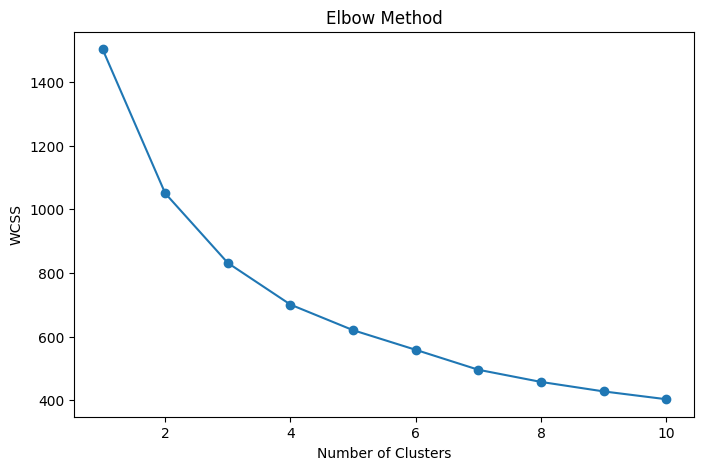

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [14]:
#Applying  K-Means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [15]:
df["Cluster"].value_counts()


Cluster
2    84
1    47
0    36
Name: count, dtype: int64

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)


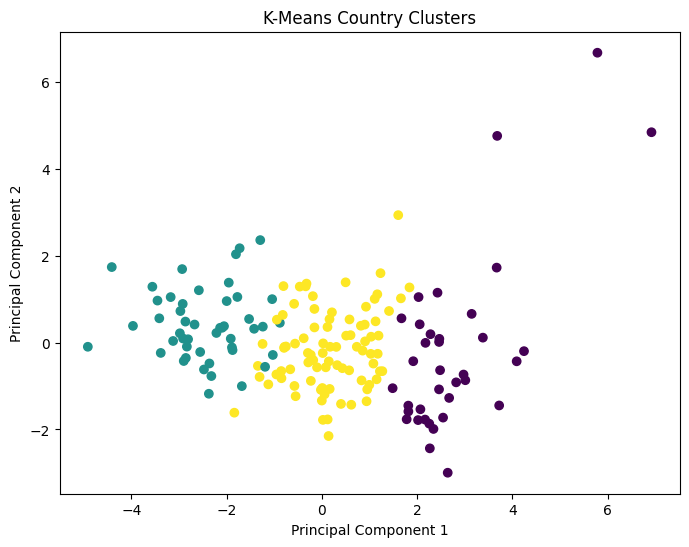

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"]
)

plt.title("K-Means Country Clusters")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()


In [18]:
df["Cluster"].value_counts()

Cluster
2    84
1    47
0    36
Name: count, dtype: int64

### Cluster Visualization using PCA

Since the dataset contains multiple dimensions, PCA was used to reduce the data into two principal components for visualization. This helps in understanding how countries are grouped after applying K-Means clustering.

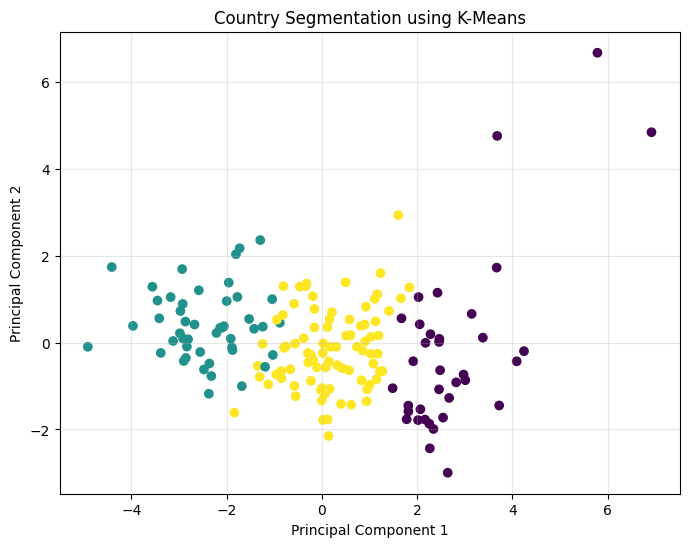

In [19]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"]
)

plt.title("Country Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.show()

## Creating Labels for Classification

The K-Means clustering algorithm generated three country segments. These segment labels are used as target classes for the classification models. The objective is to determine whether ensemble learning techniques can accurately predict the segment of a country using its socio-economic indicators.

In [20]:
df["Cluster"].value_counts()

Cluster
2    84
1    47
0    36
Name: count, dtype: int64

### Cluster Distribution Analysis

The K-Means algorithm divided the countries into three segments.

- Cluster 2 contains 84 countries and represents the largest group.
- Cluster 1 contains 47 countries.
- Cluster 0 contains 36 countries and represents the smallest segment.

The distribution indicates that most countries share similar socio-economic characteristics, while a smaller number belong to highly developed or highly underdeveloped groups.

## DBSCAN Clustering

To validate the segmentation results, DBSCAN was applied as an alternative clustering technique. Unlike K-Means, DBSCAN groups data points based on density and can identify outliers automatically.

In [21]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN"] = db_labels

df["DBSCAN"].value_counts()

DBSCAN
 0    137
-1     30
Name: count, dtype: int64

# Classification using Ensemble Learning

After generating country segments through clustering, classification models were trained to predict the segment of a country using socio-economic indicators.

Two ensemble learning techniques were evaluated:

1. Random Forest
2. XGBoost

The objective is to determine how accurately country segments can be predicted.

In [22]:
df["Target"] = df["Cluster"]
from sklearn.model_selection import train_test_split

X = df.drop(
    ["country","Cluster","DBSCAN","Target"],
    axis=1
)

y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)


Training Size: (133, 9)
Testing Size: (34, 9)


In [24]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    pred_rf
)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9705882352941176


In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

xgb_acc = accuracy_score(
    y_test,
    pred_xgb
)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9705882352941176


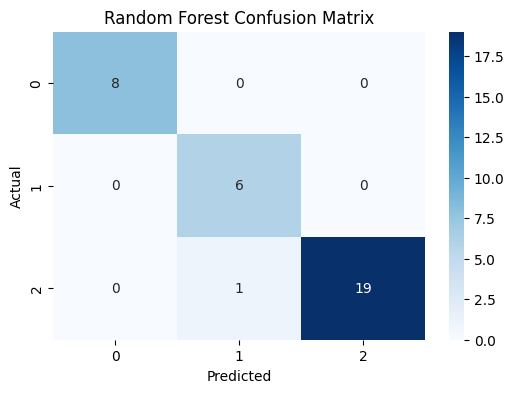

,Feature,Importance
0,child_mort,0.276790
8,gdpp,0.194674
4,income,0.167519
6,life_expec,0.157759
7,total_fer,0.141250
2,health,0.024614
5,inflation,0.015699
1,exports,0.013360
3,imports,0.008336


In [26]:
#1. Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


#2. Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance




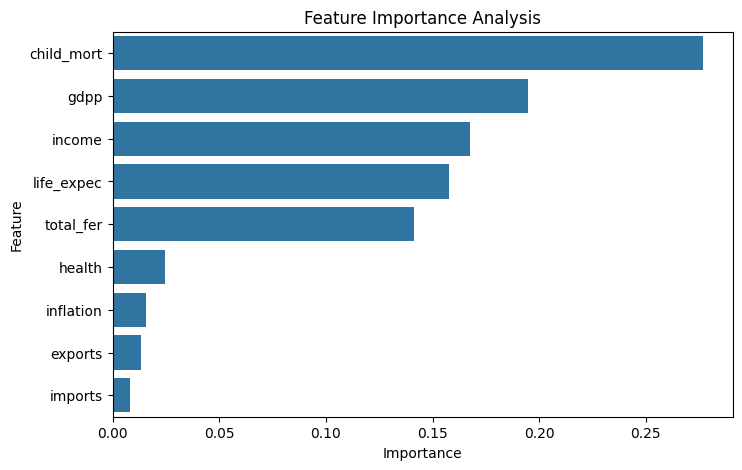

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance Analysis")

plt.show()